In [102]:
"""
Get the optimal manipulability points
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [280]:
marker_idx = 42
mani_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 32, 43, 54, 65, 76, 87, 98, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
corner_idx = [10, 120]

mani_dx_dy = np.loadtxt('mani_dx_dy.csv', delimiter=',')

mani_j = mani_dx_dy[marker_idx*2:marker_idx*2+2, :]

area_list = []
for idx in range(len(mani_list)):
    j = mani_j[:, idx*2:idx*2+2]
    u, s, v = np.linalg.svd(j)
    if mani_list[idx] in corner_idx:
        area_tmp = s[0] * s[1] * np.pi * 1 * 3/ 4
    else:
        area_tmp = s[0] * s[1] * np.pi / 2
    area_list.append(area_tmp)
    print(mani_list[idx], area_tmp, s)

# print(area_list)

1 0.047771068117463705 [0.61529491 0.04942672]
2 0.10732626189673226 [0.73812152 0.09256744]
3 0.18579595649416922 [0.81576959 0.14499361]
4 0.24022887925293704 [0.85088082 0.17973663]
5 0.30472816182678614 [0.84984364 0.22827255]
6 0.347825173806961 [0.86170737 0.25696935]
7 0.34724138330012394 [0.83586193 0.26447039]
8 0.3388768731314635 [0.78527318 0.27472697]
9 0.3127851383183085 [0.73891055 0.26948486]
10 0.3422435014821835 [0.59416645 0.24446458]
21 0.44160003760910616 [0.65713035 0.42781667]
32 0.6717940887359073 [0.73107628 0.58499696]
43 0.901979720265935 [0.79865295 0.71898328]
54 0.6858603508844734 [0.80870577 0.53991486]
65 0.5288437613039245 [0.78159257 0.43075179]
76 0.36118685406724754 [0.74384229 0.30912291]
87 0.27659815718816166 [0.69321934 0.25401463]
98 0.1826596228438813 [0.63752011 0.18240166]
109 0.12305395288895561 [0.56891413 0.13769843]
111 0.00013962131481843481 [5.77914460e-01 1.53804232e-04]
112 0.008902540311666067 [0.67911337 0.00834549]
113 0.02734180467

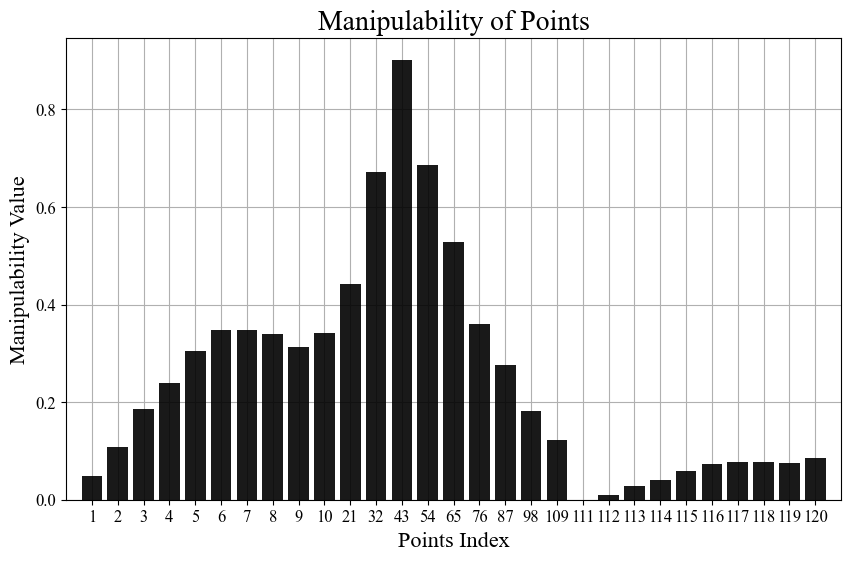

In [104]:
"""
条状图绘制操作点的可操作性值
"""
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Manipulability of Points', fontsize=20, fontname='Times New Roman')
ax.set_xlabel('Points Index', fontsize=16, fontname='Times New Roman')
ax.set_ylabel('Manipulability Value', fontsize=16, fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

bars = ax.bar(range(len(mani_list)), area_list, color='k', alpha=0.9, zorder=3)
ax.set_xlim(-1, len(mani_list))
ax.set_xticks(ticks=range(len(mani_list)), labels=mani_list)
ax.grid(True, zorder=2)

plt.show()

In [308]:
"""
得到可操作性图的相关参数
"""
top_dict_list = []
right_dict_list = []
bottom_dict_list = []
corner_dict_list1 = []
# corner_dict_list2 = []

top_list = [1, 2, 3, 4, 5, 6, 7, 8, 9]
right_list = [21, 32, 43, 54, 65, 76, 87, 98, 109]
bottom_list = [111, 112, 113, 114, 115, 116, 117, 118, 119]
corner_idx = [10, 120]

# direction1, direction2 = np.array([1, 0]), np.array([-1, 0])      # top
direction1, direction2 = np.array([-1, 0]), np.array([1, 0])      # bottom
# direction1, direction2 = np.array([0, -1]), np.array([0, 1])        # right

# direction1, direction2 = np.array([0, -1]), np.array([-1, 0])       # right-top
direction1, direction2 = np.array([-1, 0]), np.array([0, 1])        # right-bottom

points_list = [10]
for idx_value in points_list:
    idx = mani_list.index(idx_value)
    j_tmp = mani_j[:, idx*2:idx*2+2]

    j_direction1 = np.dot(j_tmp, direction1)
    j_direction2 = np.dot(j_tmp, direction2)

    u, s, v = np.linalg.svd(j_tmp)
    yflip = np.array([[1, 0], [0, -1]])
    if np.linalg.det(u) < 0 and np.linalg.det(v) < 0:
        u_yflip = u @ yflip
        v_yflip = v @ yflip
    elif np.linalg.det(u) < 0:
        raise ValueError('u is not a rotation matrix')
    elif np.linalg.det(v) < 0:
        raise ValueError('v is not a rotation matrix')
    else:
        u_yflip = u
        v_yflip = v
    
    end_x = np.dot(np.diag(s)@v_yflip.T, direction1)
    end_xx = np.dot(np.diag(s)@v_yflip.T, direction2)
    
    ang1 = np.degrees(np.arctan2(end_x[1], end_x[0]))
    ang2 = np.degrees(np.arctan2(end_xx[1], end_xx[0]))
    
    rot_ang = np.degrees(np.arctan2(u_yflip[1,0], u_yflip[0,0]))
    
    print(f'Point {idx_value} -------------------------------------------')
    print('rot', rot_ang)
    print('Arc range', ang1, ang2)
    print('Area', s)
    
    dict_tmp = {'s': s, 'rot': rot_ang, 'arc_range': [ang1, ang2], 'j_direction1': j_direction1, 'j_direction2': j_direction2, 'idx': idx_value}
    corner_dict_list1.append(dict_tmp)

Point 10 -------------------------------------------
rot 97.22582378516681
Arc range 77.54185682267656 -2.1418416459966805
Area [0.59416645 0.24446458]


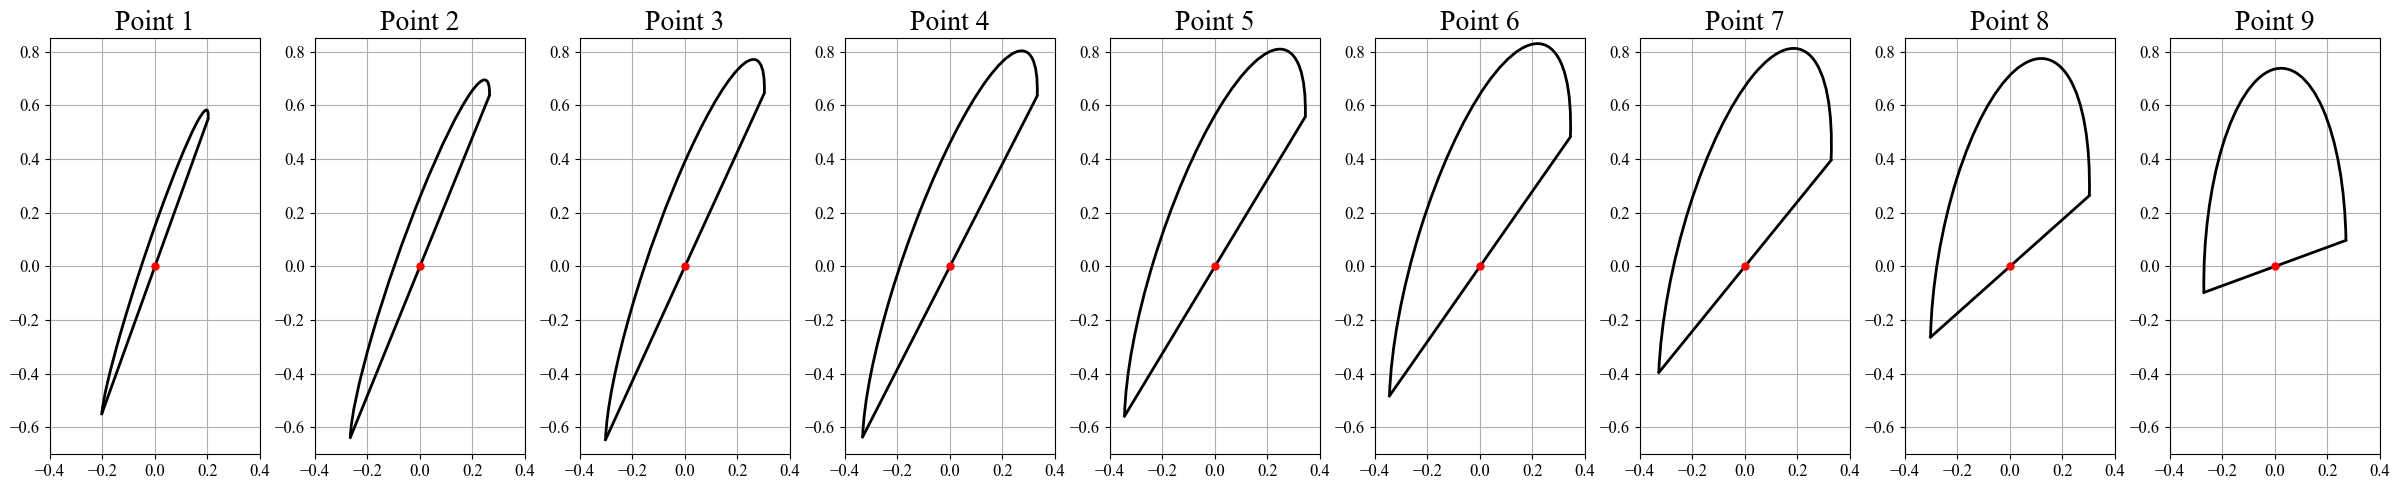

In [269]:
"""
绘制上边界操作点的可操作性图
"""
dict_list = top_dict_list
fig, axes = plt.subplots(1, 9, figsize=(24, 5), dpi=100)
for ax_idx in range(len(dict_list)):
    ax = axes[ax_idx//1]
    point_idx = dict_list[ax_idx]['idx']
    ax.set_title(f'Point {point_idx}', fontsize=20, fontname='Times New Roman')
    # ax.set_xlabel('X Direction', fontsize=16, fontname='Times New Roman')
    # ax.set_ylabel('Y Direction', fontsize=16, fontname='Times New Roman')

    ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
    # plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

    s = dict_list[ax_idx]['s']
    rot_ang = dict_list[ax_idx]['rot']
    ang1, ang2 = dict_list[ax_idx]['arc_range']
    j_direction1 = dict_list[ax_idx]['j_direction1']
    j_direction2 = dict_list[ax_idx]['j_direction2']
    
    # 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
    ellipse_arc.set_zorder(2)
    
    # 将椭圆圆弧添加到子图上
    ax.add_patch(ellipse_arc)
    ax.plot([0., j_direction1[0]], [0., j_direction1[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., j_direction2[0]], [0., j_direction2[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)
    
    ax.set_xlim([-0.4, 0.4])
    ax.set_ylim([-0.7, 0.85])
    # # 设置比例尺相等，并允许通过调整数据限制来保持比例尺
    # ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, zorder=0)

# Adjust layout
plt.tight_layout()
plt.show()

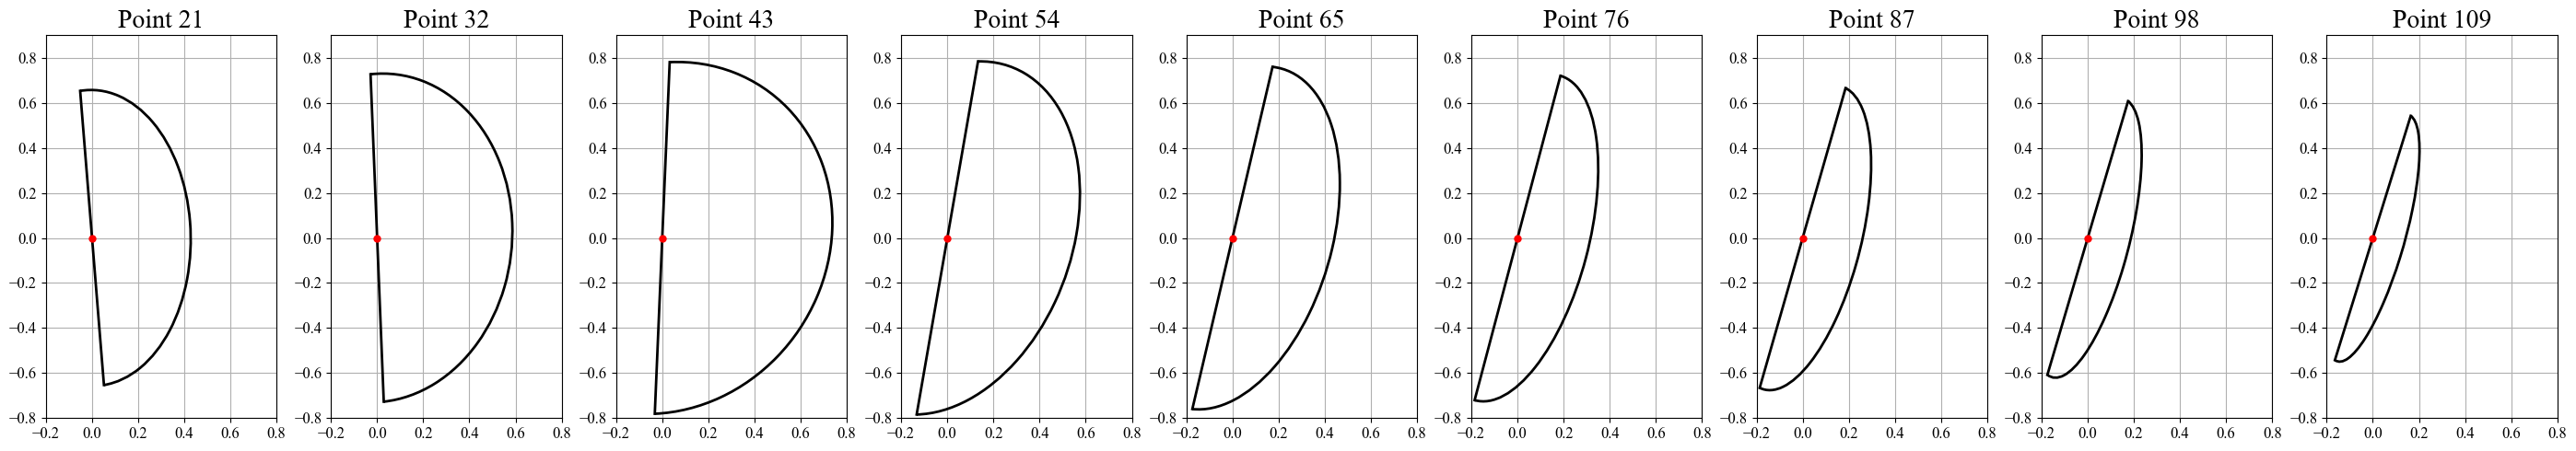

In [289]:
"""
绘制右边界操作点的可操作性图
"""
dict_list = right_dict_list
fig, axes = plt.subplots(1, 9, figsize=(28, 5), dpi=100)
for ax_idx in range(len(dict_list)):
    ax = axes[ax_idx//1]
    point_idx = dict_list[ax_idx]['idx']
    ax.set_title(f'Point {point_idx}', fontsize=20, fontname='Times New Roman')

    ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
    # plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

    s = dict_list[ax_idx]['s']
    rot_ang = dict_list[ax_idx]['rot']
    ang1, ang2 = dict_list[ax_idx]['arc_range']
    j_direction1 = dict_list[ax_idx]['j_direction1']
    j_direction2 = dict_list[ax_idx]['j_direction2']
    
    # 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
    ellipse_arc.set_zorder(2)
    
    # 将椭圆圆弧添加到子图上
    ax.add_patch(ellipse_arc)
    ax.plot([0., j_direction1[0]], [0., j_direction1[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., j_direction2[0]], [0., j_direction2[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)
    
    ax.set_xlim([-0.2, 0.8])
    ax.set_ylim([-0.8, 0.9])
    # # 设置比例尺相等，并允许通过调整数据限制来保持比例尺
    # ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, zorder=0)

# Adjust layout
plt.tight_layout()
plt.show()

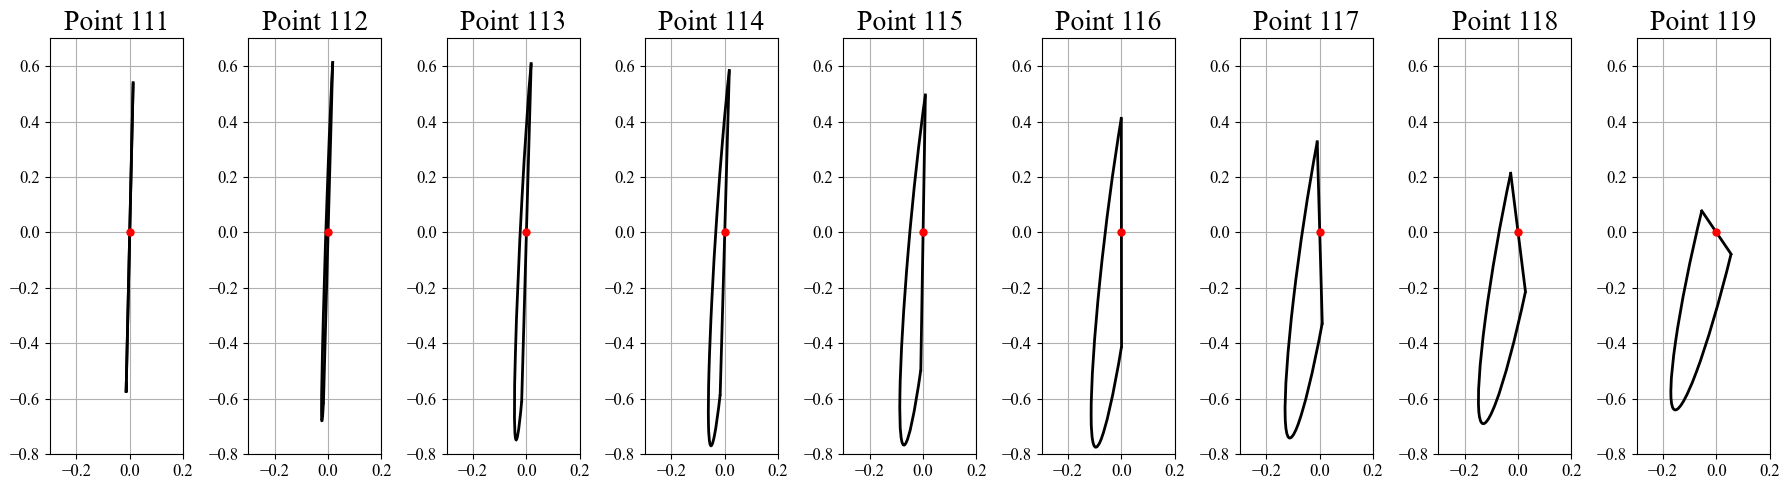

In [304]:
"""
绘制下边界操作点的可操作性图
"""
dict_list = bottom_dict_list
fig, axes = plt.subplots(1, 9, figsize=(18, 5), dpi=100)
for ax_idx in range(len(dict_list)):
    ax = axes[ax_idx//1]
    point_idx = dict_list[ax_idx]['idx']
    ax.set_title(f'Point {point_idx}', fontsize=20, fontname='Times New Roman')

    ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
    # plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

    s = dict_list[ax_idx]['s']
    rot_ang = dict_list[ax_idx]['rot']
    ang1, ang2 = dict_list[ax_idx]['arc_range']
    j_direction1 = dict_list[ax_idx]['j_direction1']
    j_direction2 = dict_list[ax_idx]['j_direction2']
    
    # 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
    ellipse_arc.set_zorder(2)
    
    # 将椭圆圆弧添加到子图上
    ax.add_patch(ellipse_arc)
    ax.plot([0., j_direction1[0]], [0., j_direction1[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., j_direction2[0]], [0., j_direction2[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)
    
    ax.set_xlim([-0.3, 0.2])
    ax.set_xticks([-0.2, 0., 0.2])
    ax.set_ylim([-0.8, 0.7])
    # # 设置比例尺相等，并允许通过调整数据限制来保持比例尺
    # ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, zorder=0)

# Adjust layout
plt.tight_layout()
plt.show()

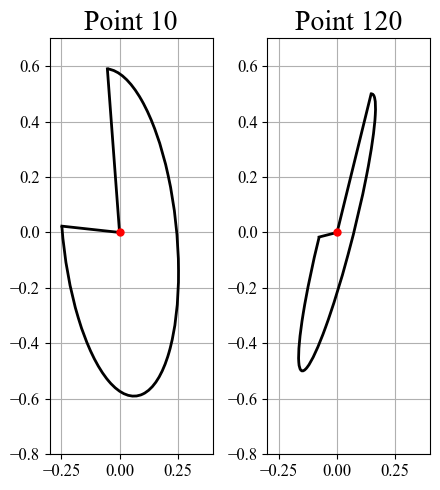

In [315]:
"""
绘制下边界操作点的可操作性图
"""
dict_list = corner_dict_list1 + corner_dict_list2
fig, axes = plt.subplots(1, 2, figsize=(4.5, 5), dpi=100)
for ax_idx in range(len(dict_list)):
    ax = axes[ax_idx//1]
    point_idx = dict_list[ax_idx]['idx']
    ax.set_title(f'Point {point_idx}', fontsize=20, fontname='Times New Roman')

    ax.tick_params(axis='both', which='major', labelsize=12)    # 设置刻度标签大小
    # plt.gca().get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴刻度值的大小

    s = dict_list[ax_idx]['s']
    rot_ang = dict_list[ax_idx]['rot']
    ang1, ang2 = dict_list[ax_idx]['arc_range']
    j_direction1 = dict_list[ax_idx]['j_direction1']
    j_direction2 = dict_list[ax_idx]['j_direction2']
    
    # 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
    ellipse_arc.set_zorder(2)
    
    # 将椭圆圆弧添加到子图上
    ax.add_patch(ellipse_arc)
    ax.plot([0., j_direction1[0]], [0., j_direction1[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., j_direction2[0]], [0., j_direction2[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)
    
    ax.set_xlim([-0.3, 0.4])
    # ax.set_xticks([-0.2, 0., 0.2])
    ax.set_ylim([-0.8, 0.7])
    # # 设置比例尺相等，并允许通过调整数据限制来保持比例尺
    # ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, zorder=0)

# Adjust layout
plt.tight_layout()
plt.show()